# Практические занятия Листок 1. СЛАУ, матрицы, квадратичные формы


In [61]:
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import hadamard
from scipy.linalg import det
from sympy import Matrix, Poly, init_printing, linsolve, reduce_inequalities, solve, symbols

init_printing()

### **1.1** Найти общее решение системы линейных уравнений.

In [62]:
A = Matrix([[1, 5, -2, 0],
            [-3, 1, 9, -5],
            [4, -8, -1, 7]])
b = Matrix([-7, 9, 0])
A_b = A.row_join(b)

print("rref(A|b):")
display(A_b.rref())


rref(A|b):


⎛⎡1  0  0  8/7   -11/7⎤           ⎞
⎜⎢                    ⎥           ⎟
⎜⎢0  1  0  -2/7  -6/7 ⎥, (0, 1, 2)⎟
⎜⎢                    ⎥           ⎟
⎝⎣0  0  1  -1/7   4/7 ⎦           ⎠

### **1.2** Найдите: a) rref  (Reduced Row EchelonForm) расширенной матрицы и b) общее решение системы линейных уравнений.

In [63]:
A_12 = Matrix([[5, -1, 5, 9, -2], [3, 0, 6, 9, -1], [2, 0, 4, 6, -1]])
b_12 = Matrix([-3, 4, 0])   # исправлено: было [0, 4, 0]
A_b_12 = A_12.row_join(b_12)

print('a) rref:')
display(A_b_12.rref()[0])

x1, x2, x3, x4, x5 = symbols('x1 x2 x3 x4 x5')
print('\nб) Общее решение:')
display(linsolve((A_12, b_12), x1, x2, x3, x4, x5))

a) rref:


⎡1  0  2  3  0  4⎤
⎢                ⎥
⎢0  1  5  6  0  7⎥
⎢                ⎥
⎣0  0  0  0  1  8⎦


б) Общее решение:


### **1.3** Найдите: 1) константу a; 2) константу b.

In [64]:
x, y, z, u = symbols('x y z u')
eq1 = 32*x + 97*y + 90*z + 48*u - 47
eq2 = 35*x + 84*y + 91*z + 54*u - 40
eq3 = 17*x + 18*y + 21*z + 13*u - 37

sol = solve((eq1, eq2, eq3), (y, z, u))
print('Решение для y через x:')
display(sol[y])

Решение для y через x:


### **1.4** Выполнить действия с матрицами.

In [65]:
A_14 = np.array([[3, 0, 2], [0, 1, 3], [2, 2, 0], [0, 1, 0]])
B_14 = np.array([[1, 2, -1, 2], [-2, -1, 1, 2], [2, 1, 1, 2]])  # исправлено: -1 во второй строке
C_14 = np.array([[0, -4, 6, 1], [2, 2, -5, -2], [2, -2, 6, 4], [1, 3, 0, 1]])

res_14 = A_14 @ B_14 + C_14
print('Результат:\n', res_14)

Результат:
 [[ 7  4  5 11]
 [ 6  4 -1  6]
 [ 0  0  6 12]
 [-1  2  1  3]]


### **1.5** Найдите определители порядка n: $min(i,j)$, $max(i,j)$, $|i-j|$.

In [66]:
n = 5
A_min = np.fromfunction(lambda i, j: np.minimum(i+1, j+1), (n, n), dtype=int)
A_max = np.fromfunction(lambda i, j: np.maximum(i+1, j+1), (n, n), dtype=int)
A_abs = np.fromfunction(lambda i, j: np.abs(i-j), (n, n), dtype=int)

print(f'Определитель min(i,j):', round(np.linalg.det(A_min)))
print(f'Определитель max(i,j):', round(np.linalg.det(A_max)))
print(f'Определитель |i-j|:', round(np.linalg.det(A_abs)))

# Общие формулы:
# min(i,j): det = 1
# max(i,j): det = (-1)^(n-1) * n
# |i-j|: det = (-1)^(n-1) * (n-1) * 2^(n-2)  (n>=2)

Определитель min(i,j): 1
Определитель max(i,j): 5
Определитель |i-j|: 32


### **1.6** Наибольшее значение определителя шестого порядка (числа -1, 0, 1).

In [67]:
def max_det_6x6():
    best_det = 0
    best_A = None
    np.random.seed(42)
    
    for trial in range(500):
        # Случайная стартовая матрица
        A = np.random.choice([-1, 0, 1], size=(6, 6))
        current_det = abs(round(det(A)))
        
        improved = True
        while improved:
            improved = False
            for i in range(6):
                for j in range(6):
                    old_val = A[i, j]
                    for new_val in [-1, 0, 1]:
                        if new_val == old_val:
                            continue
                        A[i, j] = new_val
                        new_det = abs(round(det(A)))
                        if new_det > current_det:
                            current_det = new_det
                            improved = True
                            break
                        else:
                            A[i, j] = old_val
                    if improved:
                        break
                if improved:
                    break
        
        if current_det > best_det:
            best_det = current_det
            best_A = A.copy()
            if best_det == 160:
                return best_det, best_A
    
    return best_det, best_A

best_det, best_A = max_det_6x6()
print(f"Наибольшее значение определителя: {best_det}")
print("Матрица:")
print(best_A)

Наибольшее значение определителя: 160
Матрица:
[[-1 -1  1  1  1 -1]
 [ 1 -1 -1 -1  1 -1]
 [-1 -1  1 -1 -1 -1]
 [-1 -1 -1  1 -1 -1]
 [-1 -1 -1 -1  1  1]
 [ 1 -1  1  1 -1  1]]


### **1.7** Матрица 80000x80000. Найдите: 1) определительматрицы A; 2) следматрицы, обратнойк A.

In [68]:
n = 80000
diag = np.linspace(0.99, 1.01, n)
det_block = diag[0] * diag[1] - 0.57 * 0.03
log_det = np.log(det_block) + np.sum(np.log(diag[2:]))
print(f'1) Определитель матрицы A: {np.exp(log_det):.3f}')

inv_block = np.linalg.inv(np.array([[diag[0], 0.57], [0.03, diag[1]]]))
trace_inv = inv_block[0, 0] + inv_block[1, 1] + np.sum(1.0 / diag[2:])
print(f'2) След матрицы, обратной к A: {trace_inv:.3f}')

1) Определитель матрицы A: 0.259
2) След матрицы, обратной к A: 80002.703


### **1.8** Матрица 43000x43000. Найдите обратную матрицу $B=A^{−1}$  и укажите вответе: 1) наименьший элемент матрицы B; 2) сумму элементов матрицы B.

In [69]:
n = 43000
q = (1.07)**(1/(n-1))
diag = q ** np.arange(n)
d_arith = (1.10 - 1.0) / (n - 1)
row1 = 1.0 + d_arith * np.arange(n)

# Обратная матрица для верхнетреугольной B = A^{-1}
inv_diag = 1.0 / diag
b_1j = -row1[1:] / (diag[0] * diag[1:])

min_el = min(np.min(inv_diag), np.min(b_1j))
sum_el = np.sum(inv_diag) + np.sum(b_1j)

print(f'1) Наименьший элемент матрицы B: {min_el:.3f}')
print(f'2) Сумма элементов матрицы B: {sum_el:.1f}')

1) Наименьший элемент матрицы B: -1.028
2) Сумма элементов матрицы B: -2054.4


### **1.9** Даны матрицы I, A. 1) Найдите наибольший элемент матрицы $S = S_{4,70}$. 2) Найдите наибольший элемент матрицы $B = B_4$. 3) Найдите наименьшее k,такое, что при любом n > k наибольший элемент матрицы $S_{k,n}$ меньше 0,0002.

In [70]:
gamma = 0.057
A_19 = np.array([[7*gamma, 14*gamma], [9*gamma, 1*gamma]])
I = np.eye(2)

def S_mn(m, n):
    return sum(np.linalg.matrix_power(A_19, i) for i in range(m, n + 1))

def B_m(m):
    return np.linalg.inv(I - A_19) @ np.linalg.matrix_power(A_19, m)

print(f'1) Наибольший элемент S(4,70): {np.max(S_mn(4, 70)):.6f}')
print(f'2) Наибольший элемент B(4): {np.max(B_m(4)):.6f}')

k = 1
while True:
    max_val = np.max(np.linalg.inv(I - A_19) @ np.linalg.matrix_power(A_19, k))
    if max_val < 0.0002:
        break
    k += 1
print(f'3) Наименьшее k: {k}')

1) Наибольший элемент S(4,70): 3.609679
2) Наибольший элемент B(4): 3.611175
3) Наименьшее k: 89


### **1.10** Определитель матрицы M в виде многочлена $ax^2 + bx + c$.

In [71]:
x_var = symbols('x')
M_10 = Matrix([[7, 5, 5, x_var], [2, 2, 6, 9], [3, x_var, 8, 0], [3, 1, 1, 0]])
det_M = M_10.det()

poly = Poly(det_M, x_var)
coeffs = poly.all_coeffs()
print(f'1) Коэффициент a: {coeffs[0]}')
print(f'2) Коэффициент b: {coeffs[1]}')

1) Коэффициент a: 16
2) Коэффициент b: -116


### **1.11 и 1.12** Биномиальные коэффициенты по модулю 2 и Матрица Адамара.

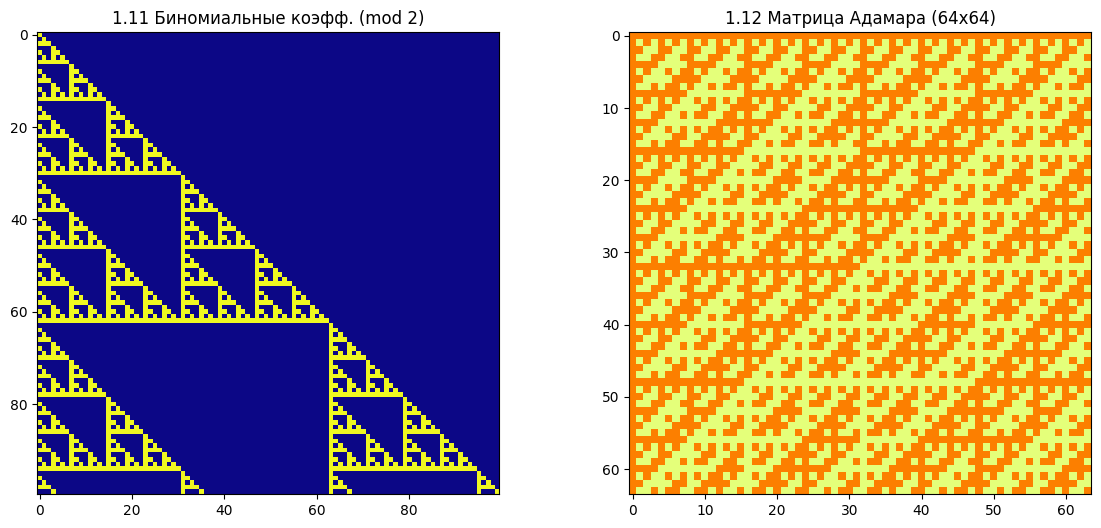

H1:
 [[1]]
H2:
 [[ 1  1]
 [ 1 -1]]
H4:
 [[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]
H4 == H2 ⊗ H2: True


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Биномиальные коэффициенты mod 2
n_bin = 100
M_bin = np.zeros((n_bin, n_bin))
for i in range(n_bin):
    for j in range(i + 1):
        M_bin[i, j] = math.comb(i + 1, j + 1) % 2
axes[0].imshow(M_bin, cmap='plasma')
axes[0].set_title('1.11 Биномиальные коэфф. (mod 2)')

# Матрица Адамара 64x64
H64 = hadamard(64)
axes[1].imshow(H64, cmap='Wistia')
axes[1].set_title('1.12 Матрица Адамара (64x64)')
plt.show()

# H1, H2, H4 и проверка H4 = H2 ⊗ H2
H1 = np.array([[1]])
H2 = np.array([[1, 1], [1, -1]])
H4 = np.kron(H2, H2)
print('H1:\n', H1)
print('H2:\n', H2)
print('H4:\n', H4)
print('H4 == H2 ⊗ H2:', np.allclose(H4, np.kron(H2, H2)))

### **1.13** Собственное значение с наибольшей мнимой частью.

In [73]:
A_13 = np.array([[14, 10, 21], [12, 15, 26], [18, 11, 27]])
eigvals, eigvecs = np.linalg.eig(A_13)

idx = np.argmax(np.imag(eigvals))
lambda_max_im = eigvals[idx]
vec = eigvecs[:, idx]
vec_normalized = vec / vec[0]  # Первая координата равна 1

print(f'1) Мнимая часть lambda: {np.imag(lambda_max_im):.3f}')
print(f'2) Действительная часть U: {np.real(vec_normalized[1]):.3f}')

1) Мнимая часть lambda: 0.345
2) Действительная часть U: 3.748


### **1.14** Найдите vинимальный многочлен матрицы.

In [74]:
A_14_minpoly = Matrix([
    [-3, 7, -6, -1, 8, -3, -2],
    [1, -5, 8, -3, -5, 4, -5],
    [1, 3, -4, 6, -2, 0, 8],
    [-1, 11, -12, 9, 3, -3, 9],
    [-3, 11, -12, 5, 8, -4, 6],
    [-3, 2, 1, -4, 4, 1, -7],
    [1, -5, 6, -2, -4, 3, -2]
])
t = symbols("t")

def minimal_polynomial(matrix, variable):
    powers = [Matrix.eye(matrix.rows)]
    for degree in range(1, matrix.rows + 1):
        powers.append(powers[-1] * matrix)
        columns = [power.reshape(matrix.rows * matrix.cols, 1) for power in powers]
        try:
            coefficients = Matrix.hstack(*columns[:-1]).gauss_jordan_solve(-columns[-1])[0]
        except ValueError:
            continue
        polynomial = variable ** degree + sum(coefficients[i] * variable ** i for i in range(degree))
        return Poly(polynomial, variable).as_expr()
    raise ValueError("Не удалось найти минимальный многочлен")

print("Минимальный многочлен:")
display(minimal_polynomial(A_14_minpoly, t))

Минимальный многочлен:


### **1.15** Собственный ортонормированный базис самосопряженного оператора.

In [75]:
A_15 = np.array([[17, -8, 4], [-8, 17, -4], [4, -4, 11]])
eigenvalues, eigenvectors = np.linalg.eigh(A_15)
print('Собственные значения:', eigenvalues)
print('Матрица в новом базисе (диагональная):\n', np.diag(eigenvalues))
print('\nМатрица перехода (ортонормированный базис - столбцы):\n', np.round(eigenvectors, 4))

Собственные значения: [ 9.  9. 27.]
Матрица в новом базисе (диагональная):
 [[ 9.  0.  0.]
 [ 0.  9.  0.]
 [ 0.  0. 27.]]

Матрица перехода (ортонормированный базис - столбцы):
 [[ 0.7327 -0.1365 -0.6667]
 [ 0.6681  0.3304  0.6667]
 [-0.1293  0.9339 -0.3333]]


### **1.16** Найдите ортогональное преобразование, приводящее квадратичную функцию к главным осям.

In [76]:
# f = 3x1^2 + 8x1x2 - 3x2^2 + 4x3^2 - 4x3x4 + x4^2
Q_16 = np.array([[3, 4, 0, 0],
                 [4, -3, 0, 0],
                 [0, 0, 4, -2],
                 [0, 0, -2, 1]])
eigvals_16, eigvecs_16 = np.linalg.eigh(Q_16)
print('Канонические коэффициенты (собственные значения):', np.round(eigvals_16, 2))
print('Матрица ортогонального преобразования:\n', np.round(eigvecs_16, 4))

Канонические коэффициенты (собственные значения): [-5.  0.  5.  5.]
Матрица ортогонального преобразования:
 [[ 0.4472 -0.      0.     -0.8944]
 [-0.8944 -0.      0.     -0.4472]
 [ 0.     -0.4472 -0.8944 -0.    ]
 [ 0.     -0.8944  0.4472 -0.    ]]


### **1.17** Тип кривой второго порядка и каноническое уравнение.

In [77]:
x, y = symbols("x y")

A_17a = Matrix([[5, 2], [2, 8]])
center_a = solve([5*x + 2*y - 16, 2*x + 8*y - 28], (x, y))
print("a) Тип: эллипс")
print("Центр:", center_a)
print("Собственные значения квадратичной формы:", A_17a.eigenvals())
print("Каноническое уравнение: U^2/9 + V^2/4 = 1")

A_17b = Matrix([[5, 6], [6, 0]])
center_b = solve([5*x + 6*y - 11, 6*x - 6], (x, y))
print("\nb) Тип: гипербола")
print("Центр:", center_b)
print("Собственные значения квадратичной формы:", A_17b.eigenvals())
print("Каноническое уравнение: U^2/4 - V^2/9 = 1")

a) Тип: эллипс
Центр: {x: 2, y: 3}
Собственные значения квадратичной формы: {9: 1, 4: 1}
Каноническое уравнение: U^2/9 + V^2/4 = 1

b) Тип: гипербола
Центр: {x: 1, y: 1}
Собственные значения квадратичной формы: {9: 1, -4: 1}
Каноническое уравнение: U^2/4 - V^2/9 = 1


### **1.18** При каких значениях параметра λ квадратичная форма Q(x) вляется положительно определенной.

In [78]:
lam = symbols("lam", real=True)
Q_18 = Matrix([[1, lam, 5], [lam, 4, 3], [5, 3, 1]])
delta_1 = Q_18[0, 0]
delta_2 = Q_18[:2, :2].det()
delta_3 = Q_18.det()

print("Условия положительной определённости (Сильвестр):")
print(f"D1 = {delta_1} > 0  →  выполнено всегда")
print(f"D2 = {delta_2} > 0  →  -2 < λ < 2")
print(f"D3 = {delta_3} > 0  →  λ² - 30λ + 105 < 0")
print(f"    Корни: λ = 15 ± √120 ≈ {15 - np.sqrt(120):.2f} и {15 + np.sqrt(120):.2f}")
print(f"    Значит: {15 - np.sqrt(120):.2f} < λ < {15 + np.sqrt(120):.2f}")
print()
print("Пересечение условий: (-2, 2) ∩ (4.05, 25.95) = ∅")
print("Ответ: нет таких λ, при которых форма положительно определена.")

Условия положительной определённости (Сильвестр):
D1 = 1 > 0  →  выполнено всегда
D2 = 4 - lam**2 > 0  →  -2 < λ < 2
D3 = -lam**2 + 30*lam - 105 > 0  →  λ² - 30λ + 105 < 0
    Корни: λ = 15 ± √120 ≈ 4.05 и 25.95
    Значит: 4.05 < λ < 25.95

Пересечение условий: (-2, 2) ∩ (4.05, 25.95) = ∅
Ответ: нет таких λ, при которых форма положительно определена.


### **1.19** При каких значениях параметра λ квадратичная форма Q(x) вляется отрицательно определенной.

In [79]:
Q_19 = Matrix([[lam, 1, -1], [1, -2, 1], [-1, 1, -3]])
d1 = Q_19[0, 0]
d2 = Q_19[:2, :2].det()
d3 = Q_19.det()

print('Условия отрицательной определенности (Сильвестр):')
sol19 = solve([d1 < 0, d2 > 0, d3 < 0], lam)
print('Решение неравенств:', sol19)
print('Ответ: λ < -3/5.')

Условия отрицательной определенности (Сильвестр):
Решение неравенств: lam < -3/5
Ответ: λ < -3/5.


### **1.20** Эквивалентность квадратичных форм $Q_1$ и $Q_2$.

In [80]:
# Q1 = 2x1^2 + 9x2^2 + 3x3^2 + 8x1x2 - 4x1x3 - 10x2x3
Q1_mat = np.array([[2, 4, -2],
                   [4, 9, -5],
                   [-2, -5, 3]])

# Q2 = 2x1^2 + 3x2^2 + 6x3^2 - 4x1x2 - 4x1x3 + 8x2x3
Q2_mat = np.array([[2, -2, -2],
                   [-2, 3, 4],
                   [-2, 4, 6]])

eig1 = np.linalg.eigvalsh(Q1_mat)
eig2 = np.linalg.eigvalsh(Q2_mat)

def signature(eigvals):
    pos = np.sum(eigvals > 1e-9)
    neg = np.sum(eigvals < -1e-9)
    return (pos, neg)

print('Сигнатура Q1:', signature(eig1))
print('Сигнатура Q2:', signature(eig2))
print('Формы эквивалентны над полем вещественных чисел, если их сигнатуры совпадают.')
print('Эквивалентны?', signature(eig1) == signature(eig2))

Сигнатура Q1: (np.int64(2), np.int64(0))
Сигнатура Q2: (np.int64(2), np.int64(0))
Формы эквивалентны над полем вещественных чисел, если их сигнатуры совпадают.
Эквивалентны? True
